In [22]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [23]:
import pandas as pd
import numpy as np

data = pd.read_csv('/Users/ugne_kam/Desktop/Crime_Data_from_2020_to_2024.csv')

In [24]:
data.shape
data.dtypes

DR_NO               int64
Date Rptd             str
DATE OCC              str
TIME OCC            int64
AREA                int64
AREA NAME             str
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc           str
Mocodes               str
Vict Age            int64
Vict Sex              str
Vict Descent          str
Premis Cd         float64
Premis Desc           str
Weapon Used Cd    float64
Weapon Desc           str
Status                str
Status Desc           str
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION              str
Cross Street          str
LAT               float64
LON               float64
dtype: object

In [25]:
missing = data.isnull().sum()
missing.sort_index


<bound method Series.sort_index of DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151598
Vict Age                0
Vict Sex           144631
Vict Descent       144643
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677678
Weapon Desc        677678
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935740
Crm Cd 3          1002580
Crm Cd 4          1004830
LOCATION                0
Cross Street       850666
LAT                     0
LON                     0
dtype: int64>

In [26]:
data = data.drop(columns=[
    'Crm Cd 1',
    'Crm Cd 2',
    'Crm Cd 3',
    'Crm Cd 4',
    'Mocodes',
    'Weapon Used Cd'
])

data['Weapon Desc'] = data['Weapon Desc'].fillna('None')
data['Vict Sex'] = data['Vict Sex'].fillna('Unknown')
data['Vict Descent'] = data['Vict Descent'].fillna('Unknown')
data['Premis Desc'] = data['Premis Desc'].fillna('Unknown')

data = data.dropna(subset=['Premis Cd', 'Status'])
data

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Vict Descent,Premis Cd,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,H,501.0,SINGLE FAMILY DWELLING,None,IC,Invest Cont,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,H,102.0,SIDEWALK,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,W,501.0,SINGLE FAMILY DWELLING,None,IC,Invest Cont,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,A,101.0,STREET,None,IC,Invest Cont,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,H,103.0,ALLEY,None,IC,Invest Cont,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,Unknown,101.0,STREET,None,IC,Invest Cont,4000 W 23RD ST,NaN,34.0362,-118.3284
1004890,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,X,503.0,HOTEL,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,1300 W SUNSET BL,NaN,34.0685,-118.2460
1004891,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,B,210.0,RESTAURANT/FAST FOOD,None,IC,Invest Cont,1700 ALBION ST,NaN,34.0675,-118.2240
1004892,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,W,102.0,SIDEWALK,STICK,IC,Invest Cont,FLOWER ST,JEFFERSON BL,34.0215,-118.2868


In [27]:
print(data['Crm Cd Desc'].unique())

<StringArray>
[                                       'THEFT OF IDENTITY',
           'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT',
      'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)',
          'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)',
 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)',
                                         'VEHICLE - STOLEN',
                                                 'BURGLARY',
                                    'BURGLARY FROM VEHICLE',
                       'THEFT PLAIN - PETTY ($950 & UNDER)',
                        'INTIMATE PARTNER - SIMPLE ASSAULT',
 ...
 'BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM',
                                                   'BIGAMY',
                                      'FAILURE TO DISPERSE',
       'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)',
             'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)',
                           'BLOCKING DOOR INDUCTION CENTER',
     

In [28]:
code_map = data.groupby('Crm Cd')['Crm Cd Desc'].first().sort_index()
print(code_map.to_string())

Crm Cd
110                                    CRIMINAL HOMICIDE
113                              MANSLAUGHTER, NEGLIGENT
121                                       RAPE, FORCIBLE
122                                      RAPE, ATTEMPTED
210                                              ROBBERY
220                                    ATTEMPTED ROBBERY
230       ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT
231         ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER
235          CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT
236                INTIMATE PARTNER - AGGRAVATED ASSAULT
237                       CHILD NEGLECT (SEE 300 W.I.C.)
250     SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT
251                    SHOTS FIRED AT INHABITED DWELLING
310                                             BURGLARY
320                                  BURGLARY, ATTEMPTED
330                                BURGLARY FROM VEHICLE
331    THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...
341    THEFT-GRAND ($950

In [29]:
data['crime_category'] = pd.cut(
    data['Crm Cd'],
    bins=[109, 123, 260, 325, 509, 522, 700, 900, 957],
    labels=[
        'Homicide & Rape',      # 110-122
        'Robbery & Assault',    # 210-251
        'Burglary',             # 310-320
        'Theft',                # 330-509
        'Vehicle Crime',        # 510-520
        'Arson & Other',        # 522-700
        'Vandalism & Weapons',  # 700-900
        'Sex Crime & Misc'      # 900-956
    ]
)

print(data.groupby('crime_category')['Crm Cd Desc'].unique().to_string())


crime_category
Homicide & Rape        [RAPE, ATTEMPTED, RAPE, FORCIBLE, CRIMINAL HOM...
Robbery & Assault      [ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...
Burglary                                 [BURGLARY, BURGLARY, ATTEMPTED]
Theft                  [THEFT OF IDENTITY, THEFT FROM MOTOR VEHICLE -...
Vehicle Crime          [VEHICLE - STOLEN, VEHICLE - ATTEMPT STOLEN, V...
Arson & Other          [INTIMATE PARTNER - SIMPLE ASSAULT, BATTERY - ...
Vandalism & Weapons    [CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10...
Sex Crime & Misc       [FIREARMS RESTRAINING ORDER (FIREARMS RO), CRI...


### New column added: 
## 'crime_category'

To simplify analysis, crime descriptions were grouped into 8 broader categories.

This approach is more robust than keyword matching


| Range | Category | Examples |
|-------|----------|----------------|
| 110 – 122 | Homicide & Rape | Criminal Homicide, Manslaughter, Forcible Rape |
| 123 – 260 | Robbery & Assault | Robbery, Aggravated Assault, Shots Fired |
| 261 – 325 | Burglary | Burglary, Attempted Burglary |
| 326 – 509 | Theft | Grand Theft, Shoplifting, Purse Snatching, Identity Theft |
| 510 – 522 | Vehicle Crime | Vehicle Stolen, Attempted Vehicle Theft |
| 523 – 700 | Arson & Other Property | Arson, Trespassing |
| 701 – 900 | Vandalism & Weapons | Vandalism, Weapon Violations |
| 901 – 956 | Sex Crime & Misc | Lewd Conduct, Contributing, Threatening Calls |


In [30]:
print(data['Vict Age'].min(), data['Vict Age'].max())
print((data['LAT'] == 0).sum())
print(data['Vict Sex'].unique())
print(data[['Date Rptd', 'DATE OCC']].dtypes)

-4 120
2240
<StringArray>
['M', 'F', 'Unknown', 'X', 'H', '-']
Length: 6, dtype: str
Date Rptd    str
DATE OCC     str
dtype: object


In [31]:
data = data[(data['Vict Age'] >= 0) & (data['Vict Age'] <= 100)]
print(data['Vict Age'].min(), data['Vict Age'].max())

data = data[(data['LAT'] != 0) & (data['LON'] != 0)]
print((data['LAT'] == 0).sum())
print((data['LON'] == 0).sum())

def clean_sex(sex):
    if sex == 'M' or sex == "F":
        return sex
    else:
        return 'Unknown'
    
data['Vict Sex'] = data['Vict Sex'].apply(clean_sex)
print(data['Vict Sex'].unique())

data['Date Rptd'] = pd.to_datetime(data['Date Rptd'])
data['DATE OCC'] = pd.to_datetime(data['DATE OCC'])
print(data[['Date Rptd', 'DATE OCC']].dtypes)


0 99
0
0
<StringArray>
['M', 'F', 'Unknown']
Length: 3, dtype: str
Date Rptd    datetime64[us]
DATE OCC     datetime64[us]
dtype: object


/var/folders/5n/254x1_w97dsddhwddlsf51fr0000gn/T/ipykernel_31434/1081353720.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date Rptd'] = pd.to_datetime(data['Date Rptd'])
/var/folders/5n/254x1_w97dsddhwddlsf51fr0000gn/T/ipykernel_31434/1081353720.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['DATE OCC'] = pd.to_datetime(data['DATE OCC'])


In [32]:
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
print(data.columns)

Index(['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name',
       'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'vict_age',
       'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_desc',
       'status', 'status_desc', 'location', 'cross_street', 'lat', 'lon',
       'crime_category'],
      dtype='str')


In [33]:
data.isnull().sum()

dr_no                  0
date_rptd              0
date_occ               0
time_occ               0
area                   0
area_name              0
rpt_dist_no            0
part_1-2               0
crm_cd                 0
crm_cd_desc            0
vict_age               0
vict_sex               0
vict_descent           0
premis_cd              0
premis_desc            0
weapon_desc            0
status                 0
status_desc            0
location               0
cross_street      848678
lat                    0
lon                    0
crime_category         0
dtype: int64

In [34]:
print(data['date_occ'].min(), data['date_occ'].max())

2020-01-01 00:00:00 2024-12-30 00:00:00


## Column names

### Record
- **`dr_no`** — Official file number (2-digit year + area ID + 5 digits)
- **`part_1-2`** — Crime classification (1 = more serious, 2 = less serious)

### Time & Date
- **`date_rptd`** — Date the crime was reported (MM/DD/YYYY)
- **`date_occ`** — Date the crime occurred (MM/DD/YYYY)
- **`time_occ`** — Time of occurrence (24-hour military time)

### Location
- **`area`** — LAPD geographic area ID (1–21)
- **`area_name`** — Name of the geographic area
- **`rpt_dist_no`** — Four-digit sub-area code within a geographic area
- **`location`** — Street address rounded to nearest hundred block (anonymised)
- **`lat`** / **`lon`** — Latitude / Longitude

### Crime
- **`crm_cd`** — Primary crime code
- **`crm_cd_desc`** — Description of the primary crime code
- **`crime_category`** — Grouped crime category derived from `crm_cd`

### Victim
- **`vict_age`** — Two-character numeric
- **`vict_sex`** — `F` Female · `M` Male · `Unknown` Unknown
- **`vict_descent`** — `A` Other Asian · `B` Black · `C` Chinese · `D` Cambodian · `F` Filipino · `G` Guamanian · `H` Hispanic/Latin/Mexican · `I` American Indian/Alaskan Native · `J` Japanese · `K` Korean · `L` Laotian · `O` Other · `P` Pacific Islander · `S` Samoan · `U` Hawaiian · `V` Vietnamese · `W` White · `X` Unknown · `Z` Asian Indian

### Premise
- **`premis_cd`** — Code for the type of structure, vehicle, or location
- **`premis_desc`** — Description of the premise code

### Weapon
- **`weapon_desc`** — Weapon used; `'None'` if no weapon involved

### Status
- **`status`** — Case status code (`IC` = Investigation Continued, default)
- **`status_desc`** — Description of the status code


In [35]:
!pip install openmeteo-requests requests-cache retry-requests

In [36]:
!pip show openmeteo-requests

Name: openmeteo_requests
Version: 1.7.5
Summary: Open-Meteo Python Library
Home-page: 
Author: 
Author-email: Patrick Zippenfenig <info@open-meteo.com>
License: 
Location: /opt/anaconda3/lib/python3.12/site-packages
Requires: niquests, openmeteo-sdk
Required-by: 


In [37]:
import sys
!{sys.executable} -m pip install openmeteo-requests

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [38]:
import sys
!{sys.executable} -m pip install requests-cache retry-requests

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [39]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 34.05,
	"longitude": -118.25,
	"start_date": "2020-01-01",
	"end_date": "2024-12-31",
	"hourly": "temperature_2m",
	"timezone": "America/Los_Angeles",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert("America/Los_Angeles")
}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 34.05975341796875°N -118.23750305175781°E
Elevation: 90.0 m asl
Timezone: b'America/Los_Angeles'b'GMT-7'
Timezone difference to GMT+0: -25200s

Hourly data
                            date  temperature_2m
0     2019-12-31 23:00:00-08:00            7.65
1     2020-01-01 00:00:00-08:00            7.50
2     2020-01-01 01:00:00-08:00            7.20
3     2020-01-01 02:00:00-08:00            9.50
4     2020-01-01 03:00:00-08:00           10.30
...                         ...             ...
43843 2024-12-31 18:00:00-08:00           12.90
43844 2024-12-31 19:00:00-08:00           12.10
43845 2024-12-31 20:00:00-08:00           11.60
43846 2024-12-31 21:00:00-08:00           11.05
43847 2024-12-31 22:00:00-08:00           10.25

[43848 rows x 2 columns]


In [40]:
data['time_occ'] = data['time_occ'] // 100

hourly_dataframe['date_only'] = hourly_dataframe['date'].dt.date
hourly_dataframe['hour'] = hourly_dataframe['date'].dt.hour

merger = (
    hourly_dataframe
    .drop_duplicates(subset=['date_only', 'hour'])
    .set_index(['date_only', 'hour'])['temperature_2m']
)

data['temp'] = pd.Series(
    list(zip(data['date_occ'].dt.date, data['time_occ']))
).map(merger).values

data['temp'] = data['temp'].astype(int)
data

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [42]:
data['time_occ'] = data['time_occ'] // 100

hourly_dataframe['date_only'] = hourly_dataframe['date'].dt.date
hourly_dataframe['hour'] = hourly_dataframe['date'].dt.hour

merger = (
    hourly_dataframe
    .drop_duplicates(subset=['date_only', 'hour'])
    .set_index(['date_only', 'hour'])['temperature_2m']
)

data['temp'] = pd.Series(
    list(zip(data['date_occ'].dt.date, data['time_occ'])),
    index=data.index
).map(merger)

data['temp'] = data['temp'].round().astype('Int64')

data

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,...,premis_desc,weapon_desc,status,status_desc,location,cross_street,lat,lon,crime_category,temp
0,211507896,2021-04-11,2020-11-07,0,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,None,IC,Invest Cont,7800 BEEMAN AV,NaN,34.2124,-118.4092,Theft,14
1,201516622,2020-10-21,2020-10-18,0,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,SIDEWALK,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,ATOLL AV,N GAULT,34.1993,-118.4203,Robbery & Assault,19
2,240913563,2024-12-10,2020-10-30,0,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,None,IC,Invest Cont,14600 SYLVAN ST,NaN,34.1847,-118.4509,Theft,16
3,210704711,2020-12-24,2020-12-24,0,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,STREET,None,IC,Invest Cont,6000 COMEY AV,NaN,34.0339,-118.3747,Theft,10
4,201418201,2020-10-03,2020-09-29,0,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,ALLEY,None,IC,Invest Cont,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,Theft,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,2024-07-24,2024-07-23,0,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,STREET,None,IC,Invest Cont,4000 W 23RD ST,NaN,34.0362,-118.3284,Vehicle Crime,20
1004890,240104953,2024-01-15,2024-01-15,0,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,HOTEL,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,1300 W SUNSET BL,NaN,34.0685,-118.2460,Vandalism & Weapons,8
1004891,240410786,2024-10-14,2024-10-11,0,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,RESTAURANT/FAST FOOD,None,IC,Invest Cont,1700 ALBION ST,NaN,34.0675,-118.2240,Theft,18
1004892,240309674,2024-04-24,2024-04-24,0,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,SIDEWALK,STICK,IC,Invest Cont,FLOWER ST,JEFFERSON BL,34.0215,-118.2868,Robbery & Assault,13


In [43]:
missing = data[data['temp'].isna()]

missing[['date_occ', 'time_occ']]

,date_occ,time_occ


In [44]:
crime_by_temp = data.groupby('temp').size().reset_index(name='crime_count')
crime_by_temp.corr()

,temp,crime_count
temp,1.000000,-0.295144
crime_count,-0.295144,1.000000


<Axes: xlabel='temp', ylabel='crime_count'>

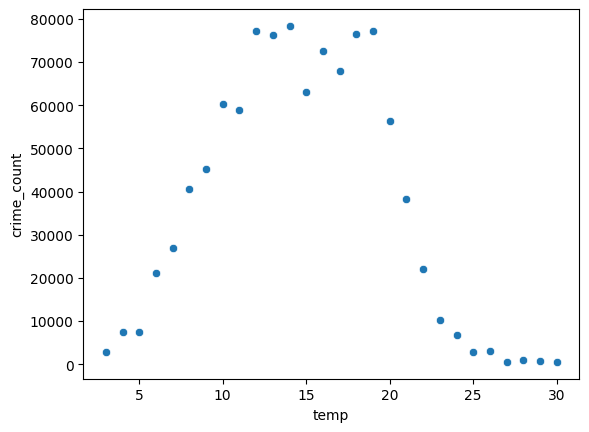

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=crime_by_temp, x='temp', y='crime_count')

<Axes: xlabel='temp', ylabel='crime_count'>

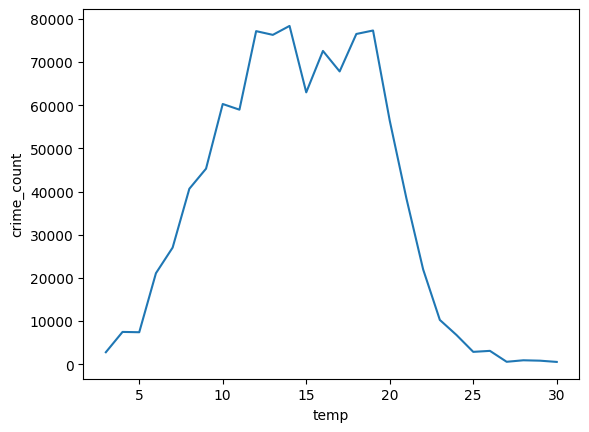

In [46]:
sns.lineplot(data=crime_by_temp, x='temp', y='crime_count')